In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image shape: (512, 640)


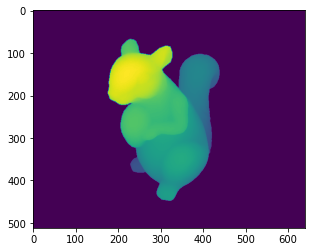

In [3]:
def load_image(fn):
    img = cv2.imread(fn)
    img = img[:,:,0]
    print("image shape:", np.shape(img))
    plt.imshow(img)
    plt.show()
    return img
img = load_image("rabbit.png")

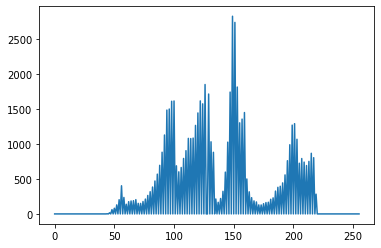

In [4]:
def get_histogram(img):
    h,_ = np.histogram(a=img, bins=256, range=(0,255))
    h[h>3000] = 3000
    h[0] = 0
    plt.plot(h)
    plt.show()
    return h
histogram = get_histogram(img)

    Algorithm: Global Thresholding Algorithm

    Start

    Chose an initial threshold value T

    Apply T to segment the image leading to two groups of pixels

     R1 are pixels with gray level > T

     R2 are pixels with gray level <= T

    Measure the average gray level values mean1 and mean2 for the pixels in R1 and R2.

    Calculate the new threshold value Tnew = (mean1 + mean2)/2

    Repeat the previous steps till the difference in T is smaller than a pre-defined threshold T0 in the successive iterations

    End

In [6]:
def get_initial_threshold(img):
    h, _ = np.histogram(a=img, bins=256, range=(0,255))
    h[0] = 0
    m = 1
    n = 255
    while m<n and h[m]==0:
        m+=1
    while n>m and h[n]==0:
        n-=1
    return (m+n)//2

In [7]:
def get_global_threshold(img):
    t0 = 255
    t1 = get_initial_threshold(img)
    while t1 < t0:
        m1 = img > t1
        m2 = img <= t1
        r1 = img[m1]
        r2 = img[m2]
        mean1 = np.sum(r1)//np.size(r1)
        mean2 = np.sum(r2)//np.size(r2)
        t0 = t1
        t1 = (mean1 + mean2)//2
    return int(t1)

t = get_global_threshold(img)
print(t)

71


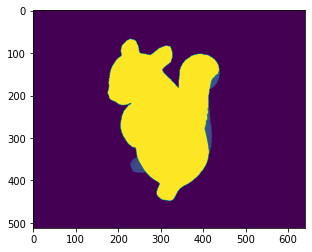

In [8]:
def segment_image(img, t):
    mask = img > t
    img1 = img.copy()
    img1[mask] = 255
    plt.imshow(img1)
    plt.show()

segment_image(img,t)

In [10]:
def split_image(img, M, N):
    return [img[x:x+M,y:y+N] for x in range(0,img.shape[0],M) for y in range(0,img.shape[1],N)]

tiles = split_image(img, 100, 100)

In [16]:
def get_global_threshold(img):
    t0 = 255
    t1 = get_initial_threshold(img)
    while t1 < t0:
        print(t1)
        m1 = img > t1
        m2 = img <= t1
        r1 = img[m1]
        r2 = img[m2]
        s1 = np.size(r1)
        s2 = np.size(r2)
        if s1==0:
            pass
        elif s2==0:
            pass
        else:
            mean1 = np.sum(r1)//np.size(r1)
            mean2 = np.sum(r2)//np.size(r2)
            t0 = t1
            t1 = (mean1 + mean2)//2
    return int(t1)

threshold 163


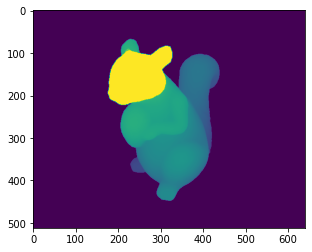

threshold 122


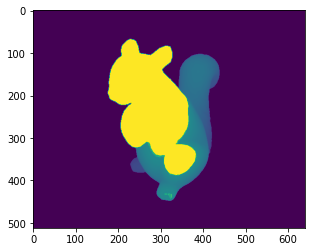

threshold 114


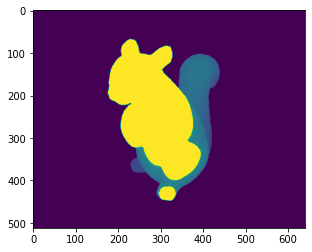

threshold 102


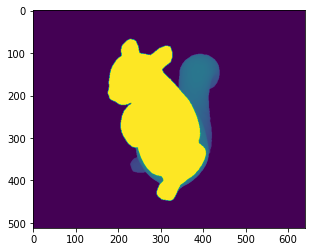

threshold 101


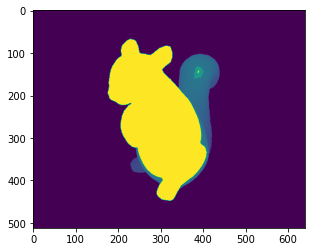

threshold 98


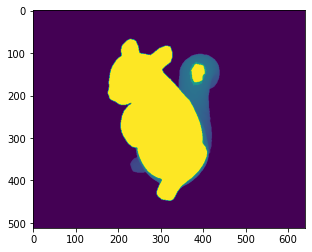

threshold 80


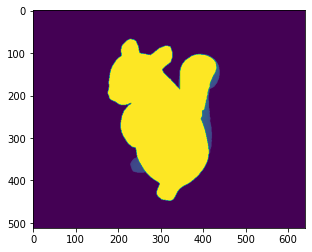

threshold 63


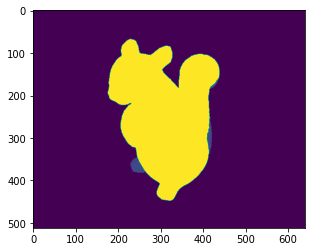

threshold 60


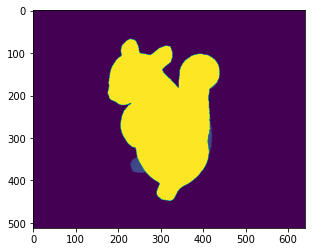

threshold 56


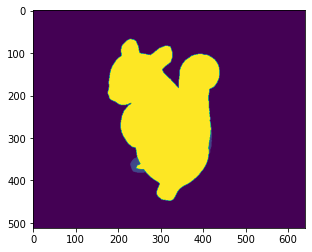

threshold 54


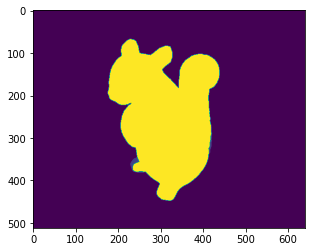

threshold 43


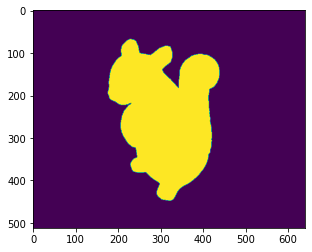

threshold 42


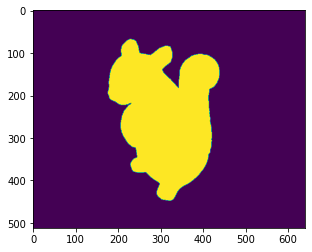

threshold 36


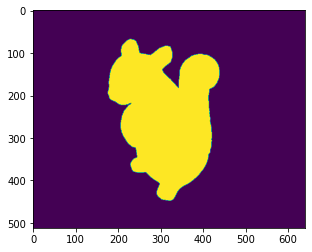

In [17]:
for t in th:
    print("threshold", t)
    segment_image(img, t)